🖥️  Device: cuda
  STEP 1: FETCHING + PROCESSING ALL STOCKS
  📥 Adani Enterprises (ADANIENT.NS)... ✅ 2325 rows
  📥 Adani Ports and SEZ (ADANIPORTS.NS)... ✅ 2325 rows
  📥 Apollo Hospitals (APOLLOHOSP.NS)... ✅ 2325 rows
  📥 Asian Paints (ASIANPAINT.NS)... ✅ 2325 rows
  📥 Axis Bank (AXISBANK.NS)... ✅ 2325 rows
  📥 Bajaj Auto (BAJAJ-AUTO.NS)... ✅ 2324 rows
  📥 Bajaj Finserv (BAJAJFINSV.NS)... ✅ 2325 rows
  📥 Bajaj Finance (BAJFINANCE.NS)... ✅ 2325 rows
  📥 Bharti Airtel (BHARTIARTL.NS)... ✅ 2325 rows
  📥 Bharat Petroleum (BPCL.NS)... ✅ 2325 rows
  📥 Britannia Industries (BRITANNIA.NS)... ✅ 2319 rows
  📥 Cipla (CIPLA.NS)... ✅ 2325 rows
  📥 Coal India (COALINDIA.NS)... ✅ 2325 rows
  📥 Divi's Laboratories (DIVISLAB.NS)... ✅ 2325 rows
  📥 Dr. Reddy's Laboratories (DRREDDY.NS)... ✅ 2325 rows
  📥 Eicher Motors (EICHERMOT.NS)... ✅ 2325 rows
  📥 Grasim Industries (GRASIM.NS)... ✅ 2325 rows
  📥 HCL Technologies (HCLTECH.NS)... ✅ 2325 rows
  📥 HDFC Bank (HDFCBANK.NS)... ✅ 2325 rows
  📥 HDFC Life Ins

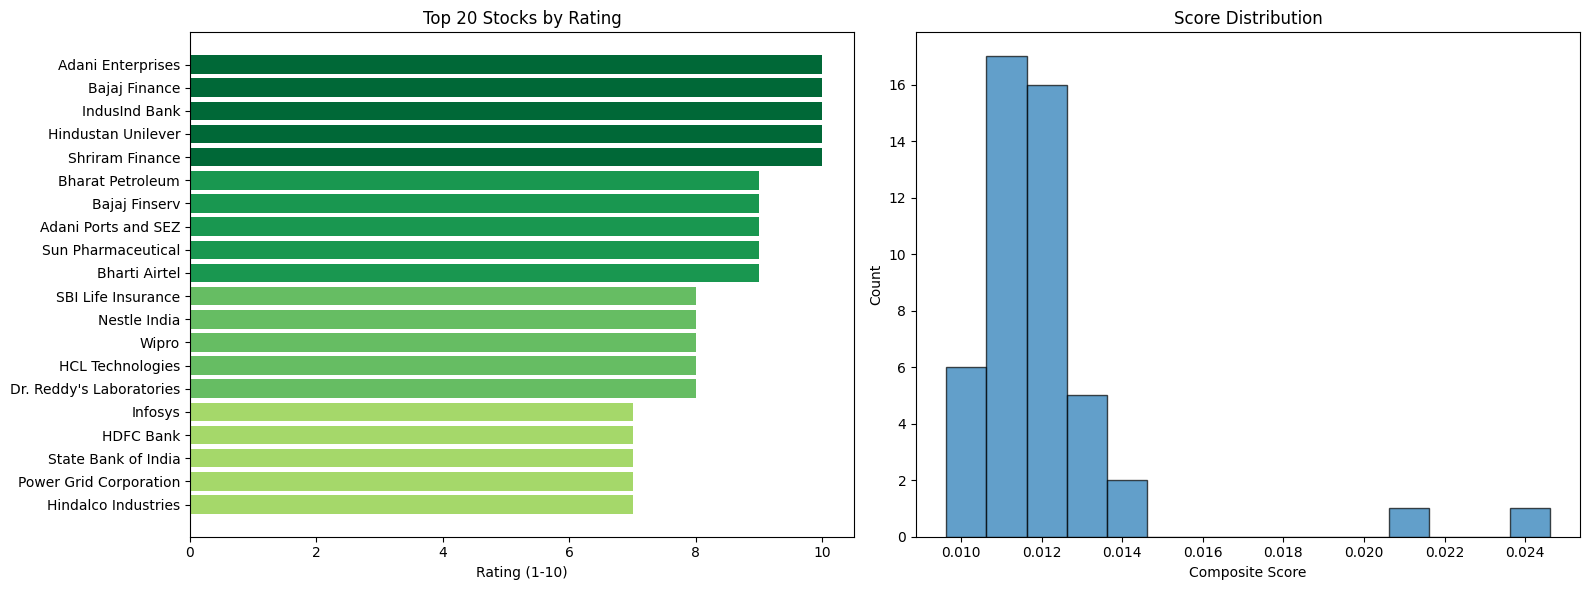

📊 Chart saved → ratings_chart.png


In [6]:
!pip install -q yfinance lightgbm ta
import yfinance as yf
import pandas as pd
import numpy as np
import ta
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from pathlib import Path
import joblib
import logging
import time
import warnings

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")

# TICKERS
NIFTY50_TICKERS = {
    "ADANIENT.NS": "Adani Enterprises",
    "ADANIPORTS.NS": "Adani Ports and SEZ",
    "APOLLOHOSP.NS": "Apollo Hospitals",
    "ASIANPAINT.NS": "Asian Paints",
    "AXISBANK.NS": "Axis Bank",
    "BAJAJ-AUTO.NS": "Bajaj Auto",
    "BAJAJFINSV.NS": "Bajaj Finserv",
    "BAJFINANCE.NS": "Bajaj Finance",
    "BHARTIARTL.NS": "Bharti Airtel",
    "BPCL.NS": "Bharat Petroleum",
    "BRITANNIA.NS": "Britannia Industries",
    "CIPLA.NS": "Cipla",
    "COALINDIA.NS": "Coal India",
    "DIVISLAB.NS": "Divi's Laboratories",
    "DRREDDY.NS": "Dr. Reddy's Laboratories",
    "EICHERMOT.NS": "Eicher Motors",
    "GRASIM.NS": "Grasim Industries",
    "HCLTECH.NS": "HCL Technologies",
    "HDFCBANK.NS": "HDFC Bank",
    "HDFCLIFE.NS": "HDFC Life Insurance",
    "HEROMOTOCO.NS": "Hero MotoCorp",
    "HINDALCO.NS": "Hindalco Industries",
    "HINDUNILVR.NS": "Hindustan Unilever",
    "ICICIBANK.NS": "ICICI Bank",
    "INDUSINDBK.NS": "IndusInd Bank",
    "INFY.NS": "Infosys",
    "ITC.NS": "ITC",
    "JSWSTEEL.NS": "JSW Steel",
    "KOTAKBANK.NS": "Kotak Mahindra Bank",
    "LT.NS": "Larsen & Toubro",
    "M&M.NS": "Mahindra & Mahindra",
    "MARUTI.NS": "Maruti Suzuki",
    "NESTLEIND.NS": "Nestle India",
    "NTPC.NS": "NTPC",
    "ONGC.NS": "ONGC",
    "POWERGRID.NS": "Power Grid Corporation",
    "RELIANCE.NS": "Reliance Industries",
    "SBILIFE.NS": "SBI Life Insurance",
    "SBIN.NS": "State Bank of India",
    "SHRIRAMFIN.NS": "Shriram Finance",
    "SUNPHARMA.NS": "Sun Pharmaceutical",
    "TATACONSUM.NS": "Tata Consumer Products",
    "TATASTEEL.NS": "Tata Steel",
    "TCS.NS": "Tata Consultancy Services",
    "TECHM.NS": "Tech Mahindra",
    "TITAN.NS": "Titan Company",
    "ULTRACEMCO.NS": "UltraTech Cement",
    "WIPRO.NS": "Wipro",
}

TARGET_COLS = ["future_return_10d", "future_return_20d", "future_return_30d"]
SEQ_LEN = 30

# STEP 1: FETCH + CLEAN + FEATURES
def fetch_and_process_stock(ticker, company):
    """Download → Clean → Feature engineering for one stock."""
    try:
        df = yf.download(ticker, period="10y", interval="1d",
                         auto_adjust=False, progress=False)
        if df.empty:
            return None

        df.reset_index(inplace=True)

        # handle multi-level columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [col[0] if col[1] == '' else col[0] for col in df.columns]

        if "Date" not in df.columns and "Datetime" in df.columns:
            df.rename(columns={"Datetime": "Date"}, inplace=True)

        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

        for col in ["Open", "High", "Low", "Close", "Volume"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df.dropna(subset=["Date", "Open", "High", "Low", "Close"], inplace=True)
        df = df[(df["Open"] > 0) & (df["High"] > 0) & (df["Low"] > 0) & (df["Close"] > 0)]
        df = df[df["Volume"] >= 0]

        df.sort_values("Date", inplace=True)
        df.drop_duplicates(subset="Date", keep="first", inplace=True)
        df.set_index("Date", inplace=True)
        df = df.asfreq("B")
        df.ffill(inplace=True)
        df.reset_index(inplace=True)

        # FEATURES
        c = df["Close"]

        # Returns
        df["daily_return"] = c.pct_change()
        df["log_return"] = np.log(c / c.shift(1))

        # Trend
        df["ema_20"] = ta.trend.ema_indicator(c, 20)
        df["ema_50"] = ta.trend.ema_indicator(c, 50)
        df["sma_100"] = ta.trend.sma_indicator(c, 100)
        df["price_trend_252"] = c.rolling(252).mean()
        df["trend_residual"] = (c - df["price_trend_252"]) / df["price_trend_252"]

        # Momentum
        df["rsi_14"] = ta.momentum.rsi(c, 14)
        df["macd_diff"] = ta.trend.macd_diff(c)
        df["roc_10"] = c.pct_change(10)

        # Volatility
        df["volatility_20"] = df["daily_return"].rolling(20).std()
        df["volatility_60"] = df["daily_return"].rolling(60).std()
        df["hl_range"] = (df["High"] - df["Low"]) / c
        df["atr_14"] = ta.volatility.average_true_range(df["High"], df["Low"], c, 14)
        df["vol_regime"] = (df["volatility_20"] > df["volatility_20"].rolling(252).mean().shift(1)).astype(int)

        # Volume
        df["volume_change"] = df["Volume"].pct_change()
        df["volume_sma_20"] = df["Volume"].rolling(20).mean()
        vol_std = df["Volume"].rolling(20).std()
        df["volume_zscore_20"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / vol_std
        df["price_volume_trend"] = df["daily_return"] * df["volume_change"]
        df["price_volume_divergence"] = df["daily_return"] - df["volume_change"]

        # Relative Strength
        df["rs_50"] = c / c.rolling(50).mean()
        df["rs_200"] = c / c.rolling(200).mean()

        # Drawdown
        df["drawdown"] = c / c.cummax() - 1

        # Targets
        df["future_return_10d"] = c.shift(-10) / c - 1
        df["future_return_20d"] = c.shift(-20) / c - 1
        df["future_return_30d"] = c.shift(-30) / c - 1

        # Drop warmup
        df = df.iloc[252:]

        df["Ticker"] = ticker
        df["Company"] = company

        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)

        return df

    except Exception as e:
        logging.warning(f"⚠️ Failed {ticker}: {e}")
        return None


print("=" * 60)
print("  STEP 1: FETCHING + PROCESSING ALL STOCKS")
print("=" * 60)

all_dfs = []
failed = []

for ticker, company in NIFTY50_TICKERS.items():
    print(f"  📥 {company} ({ticker})...", end=" ")
    df = fetch_and_process_stock(ticker, company)
    if df is not None and len(df) > 100:
        all_dfs.append(df)
        print(f"✅ {len(df)} rows")
    else:
        failed.append(ticker)
        print("❌ skipped")
    time.sleep(1)

master_df = pd.concat(all_dfs, ignore_index=True)
master_df.sort_values("Date", inplace=True)

print(f"\n✅ Total: {len(all_dfs)} stocks, {len(master_df)} rows")
if failed:
    print(f"❌ Failed: {failed}")


# STEP 2: PREPARE DATA SPLITS
print("\n" + "=" * 60)
print("  STEP 2: PREPARING TRAIN / VAL / TEST SPLITS")
print("=" * 60)

EXCLUDE = {"Date", "Ticker", "Company"} | set(TARGET_COLS)
FEATURE_COLS = [c for c in master_df.columns
                if c not in EXCLUDE and pd.api.types.is_numeric_dtype(master_df[c])]

print(f"  Features: {len(FEATURE_COLS)}")

# Time split
unique_dates = sorted(master_df["Date"].unique())
n = len(unique_dates)
train_end = unique_dates[int(n * 0.70)]
val_end   = unique_dates[int(n * 0.85)]

train_df = master_df[master_df["Date"] <= train_end].copy()
val_df   = master_df[(master_df["Date"] > train_end) & (master_df["Date"] <= val_end)].copy()
test_df  = master_df[master_df["Date"] > val_end].copy()

print(f"  Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")


# STEP 3: TRAIN LIGHTGBM
print("\n" + "=" * 60)
print("  STEP 3: TRAINING LIGHTGBM")
print("=" * 60)

scaler_lgb = StandardScaler()

X_tr_lgb = scaler_lgb.fit_transform(train_df[FEATURE_COLS].astype(float))
X_va_lgb = scaler_lgb.transform(val_df[FEATURE_COLS].astype(float))
X_te_lgb = scaler_lgb.transform(test_df[FEATURE_COLS].astype(float))

lgb_params = dict(
    objective="regression",
    metric="rmse",
    boosting_type="gbdt",

    num_leaves=118,
    max_depth=5,
    learning_rate=0.297792485562755,

    feature_fraction=0.8170503785723984,
    bagging_fraction=0.6905302271459494,
    bagging_freq=5,

    reg_alpha=2.7051981257040345,
    reg_lambda=0.5968930548610707,
    min_child_samples=63,

    verbose=-1,
    n_jobs=-1,
)

lgb_models = {}
lgb_test_preds = {}

for target in TARGET_COLS:
    print(f"  🌳 Training → {target}")

    ds_tr = lgb.Dataset(X_tr_lgb, label=train_df[target].values)
    ds_va = lgb.Dataset(X_va_lgb, label=val_df[target].values, reference=ds_tr)

    model = lgb.train(
        lgb_params, ds_tr, num_boost_round=2000,
        valid_sets=[ds_tr, ds_va], valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(75), lgb.log_evaluation(500)],
    )

    preds = model.predict(X_te_lgb)
    rmse = np.sqrt(np.mean((test_df[target].values - preds) ** 2))
    print(f"     TEST RMSE = {rmse:.6f}")

    lgb_models[target] = model
    lgb_test_preds[target] = preds

print("  ✅ LightGBM done")



# STEP 4: BUILD SEQUENCES FOR LSTM & CNN
print("\n" + "=" * 60)
print("  STEP 4: BUILDING SEQUENCES")
print("=" * 60)

scaler_seq = StandardScaler()
train_df[FEATURE_COLS] = scaler_seq.fit_transform(train_df[FEATURE_COLS].astype(float))
val_df[FEATURE_COLS]   = scaler_seq.transform(val_df[FEATURE_COLS].astype(float))
test_df[FEATURE_COLS]  = scaler_seq.transform(test_df[FEATURE_COLS].astype(float))


def build_sequences(df, seq_len=SEQ_LEN):
    X, y, meta = [], [], []
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    for ticker in df["Ticker"].unique():
        temp = df[df["Ticker"] == ticker]
        feat_arr = temp[FEATURE_COLS].values.astype(np.float32)
        tgt_arr  = temp[TARGET_COLS].values.astype(np.float32)
        dates    = temp["Date"].values

        for i in range(seq_len, len(feat_arr)):
            X.append(feat_arr[i - seq_len : i])
            y.append(tgt_arr[i])
            meta.append({"Date": dates[i], "Ticker": ticker})

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DataFrame(meta)


X_tr, y_tr, _ = build_sequences(train_df)
X_va, y_va, _ = build_sequences(val_df)
X_te, y_te, test_meta = build_sequences(test_df)

print(f"  Train: {X_tr.shape}  |  Val: {X_va.shape}  |  Test: {X_te.shape}")

BATCH_SIZE = 256
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
                       batch_size=BATCH_SIZE, shuffle=True)
va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va)),
                       batch_size=BATCH_SIZE)


# STEP 5: TRAIN LSTM
print("\n" + "=" * 60)
print("  STEP 5: TRAINING LSTM")
print("=" * 60)

class LSTMModel(nn.Module):
    def __init__(self, input_dim,
                 hidden=64,
                 layers=2,
                 dropout=0.49426018164424035,
                 output_dim=3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden,
            layers,
            batch_first=True,
            dropout=dropout
        )

        self.head = nn.Sequential(
            nn.BatchNorm1d(hidden),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


def train_model(model, name,
                epochs,
                lr,
                weight_decay,
                patience):

    optimiser = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, patience=5, factor=0.5
    )

    criterion = nn.HuberLoss(delta=0.05)

    best_val, patience_ctr = float("inf"), 0
    best_state = None

    for epoch in range(1, epochs + 1):

        # ───── Train ─────
        model.train()
        loss_sum = 0

        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            loss = criterion(model(xb), yb)
            optimiser.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()

            loss_sum += loss.item() * xb.size(0)

        tr_loss = loss_sum / len(tr_loader.dataset)

        # ───── Validation ─────
        model.eval()
        loss_sum = 0

        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss_sum += criterion(model(xb), yb).item() * xb.size(0)

        va_loss = loss_sum / len(va_loader.dataset)
        scheduler.step(va_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"    Epoch {epoch:>3}/{epochs}  train={tr_loss:.6f}  val={va_loss:.6f}")

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"    Early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_te).to(DEVICE)).cpu().numpy()

    for i, t in enumerate(TARGET_COLS):
        rmse = np.sqrt(np.mean((y_te[:, i] - preds[:, i]) ** 2))
        print(f"    {t}  TEST RMSE = {rmse:.6f}")

    return model, preds


n_features = len(FEATURE_COLS)

#---after tuning hyper-parameters---
lstm_model = LSTMModel(input_dim=n_features).to(DEVICE)
lstm_model, lstm_preds = train_model(lstm_model, name="LSTM", epochs=34,
    lr=0.000304867088345807,
    weight_decay=0.0004881375191603673,
    patience=17
)
print("  ✅ LSTM done")


# STEP 6: TRAIN 1D-CNN
print("\n" + "=" * 60)
print("  STEP 6: TRAINING 1D-CNN")
print("=" * 60)

class CNN1DModel(nn.Module):
    def __init__(self, n_features, output_dim=3):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.GELU(),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.AdaptiveAvgPool1d(1),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2114585856946446),
            nn.Linear(32, output_dim),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.head(self.conv(x))

#---after tuning hyper-parameters---
cnn_model = CNN1DModel(n_features=n_features).to(DEVICE)
cnn_model, cnn_preds = train_model( cnn_model, name="CNN", epochs=49,
    lr=0.0065543823435462835,
    weight_decay=9.083381663660597e-06,
    patience=7
)
print("  ✅ CNN done")


# STEP 7: ENSEMBLE → COMPOSITE SCORE → RATINGS
print("\n" + "=" * 60)
print("  STEP 7: ENSEMBLE → RATINGS")
print("=" * 60)

# ── Weights ──
MODEL_W   = {"lgb": 0.1852, "lstm": 0.4538, "cnn": 0.3610}
HORIZON_W = {
    "future_return_10d": 0.20,
    "future_return_20d": 0.30,
    "future_return_30d": 0.50,
}

# ── Get latest prediction per stock ──
# Use the LAST sequence per ticker from test set

latest_per_stock = {}
for idx, row in test_meta.iterrows():
    latest_per_stock[row["Ticker"]] = idx  # keeps overwriting → last index wins

results = []

for ticker, last_idx in latest_per_stock.items():
    composite = 0.0

    for i, t in enumerate(TARGET_COLS):
        # LGB: use last test row for this ticker
        ticker_test_mask = test_df[test_df["Ticker"] == ticker]
        if len(ticker_test_mask) == 0:
            continue
        lgb_idx = ticker_test_mask.index[-1]
        lgb_row_pos = test_df.index.get_loc(lgb_idx)

        lgb_pred  = lgb_test_preds[t][lgb_row_pos] if lgb_row_pos < len(lgb_test_preds[t]) else 0
        lstm_pred = lstm_preds[last_idx][i]
        cnn_pred  = cnn_preds[last_idx][i]

        blended = (MODEL_W["lgb"]  * lgb_pred +
                   MODEL_W["lstm"] * lstm_pred +
                   MODEL_W["cnn"]  * cnn_pred)

        composite += HORIZON_W[t] * blended

    company = NIFTY50_TICKERS.get(ticker, ticker)
    results.append({
        "Ticker": ticker,
        "Company": company,
        "composite_score": composite,
    })

ratings_df = pd.DataFrame(results)
ratings_df["percentile"] = ratings_df["composite_score"].rank(pct=True)
ratings_df["rating"] = np.ceil(ratings_df["percentile"] * 10).astype(int).clip(1, 10)
ratings_df.sort_values("rating", ascending=False, inplace=True)


# STEP 8: DISPLAY RESULTS
print("\n" + "=" * 72)
print(f"{'NIFTY-50 STOCK RATINGS':^72}")
print("=" * 72)
print(f"{'Rating':>6}  {'Company':<30}  {'Ticker':<18}  {'Score':>10}")
print("-" * 72)

for _, row in ratings_df.iterrows():
    stars = "⭐" * row["rating"]
    print(f"{row['rating']:>6}  {str(row['Company']):<30}  {row['Ticker']:<18}  "
          f"{row['composite_score']:>10.5f}  {stars}")

print("=" * 72)

# ── Save ──
ratings_df.to_csv("stock_ratings.csv", index=False)
print("\n💾 Saved → stock_ratings.csv")


# STEP 9: EVALUATION METRICS
print("\n" + "=" * 60)
print("  EVALUATION METRICS (Test Period)")
print("=" * 60)

for i, t in enumerate(TARGET_COLS):
    print(f"\n  📊 {t}:")

    # LGB
    lgb_p = lgb_test_preds[t][:len(y_te)]
    rmse = np.sqrt(np.mean((y_te[:, i] - lgb_p) ** 2))
    dir_acc = (np.sign(lgb_p) == np.sign(y_te[:, i])).mean()
    print(f"     LGB   RMSE={rmse:.5f}  DirAcc={dir_acc:.2%}")

    # LSTM
    rmse = np.sqrt(np.mean((y_te[:, i] - lstm_preds[:, i]) ** 2))
    dir_acc = (np.sign(lstm_preds[:, i]) == np.sign(y_te[:, i])).mean()
    print(f"     LSTM  RMSE={rmse:.5f}  DirAcc={dir_acc:.2%}")

    # CNN
    rmse = np.sqrt(np.mean((y_te[:, i] - cnn_preds[:, i]) ** 2))
    dir_acc = (np.sign(cnn_preds[:, i]) == np.sign(y_te[:, i])).mean()
    print(f"     CNN   RMSE={rmse:.5f}  DirAcc={dir_acc:.2%}")

    # Ensemble
    ens = MODEL_W["lgb"] * lgb_p + MODEL_W["lstm"] * lstm_preds[:, i] + MODEL_W["cnn"] * cnn_preds[:, i]
    rmse = np.sqrt(np.mean((y_te[:, i] - ens) ** 2))
    dir_acc = (np.sign(ens) == np.sign(y_te[:, i])).mean()
    ic, _ = spearmanr(ens, y_te[:, i])
    print(f"     ENS   RMSE={rmse:.5f}  DirAcc={dir_acc:.2%}  IC={ic:.4f}")

print("\n✅ PIPELINE COMPLETE!")


# STEP 10: VISUALIZATION
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating distribution
axes[0].barh(ratings_df["Company"].head(20), ratings_df["rating"].head(20),
             color=plt.cm.RdYlGn(ratings_df["rating"].head(20) / 10))
axes[0].set_xlabel("Rating (1-10)")
axes[0].set_title("Top 20 Stocks by Rating")
axes[0].invert_yaxis()

# Score distribution
axes[1].hist(ratings_df["composite_score"], bins=15, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Composite Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Score Distribution")

plt.tight_layout()
plt.savefig("ratings_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("📊 Chart saved → ratings_chart.png")